In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('heart_cleveland_upload.csv')
print(df.shape)      # (297, 14)
df.head()

(297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [12]:
# These columns are nominal (categories with no order)
nominal_cols = ['cp', 'restecg', 'slope', 'thal']

df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print("Shape after encoding:", df_encoded.shape)
print("New columns:", df_encoded.columns.tolist())

Shape after encoding: (297, 19)
New columns: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'condition', 'cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2', 'slope_1', 'slope_2', 'thal_1', 'thal_2']


In [13]:
X = df_encoded.drop('condition', axis=1)
y = df_encoded['condition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # ← ensures equal class ratio in both sets
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Train class split: {y_train.value_counts().to_dict()}")
print(f"Test class split:  {y_test.value_counts().to_dict()}")

Train size: 237 | Test size: 60
Train class split: {0: 128, 1: 109}
Test class split:  {0: 32, 1: 28}


In [15]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)   # fit AND transform on train
X_test_sc  = scaler.transform(X_test)        # ONLY transform on test

# ⚠️ Never fit_transform on test — that causes data leakage!

In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)

    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'cm':        confusion_matrix(y_test, y_pred)
    }

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred))


  Logistic Regression
              precision    recall  f1-score   support

           0       0.86      1.00      0.93        32
           1       1.00      0.82      0.90        28

    accuracy                           0.92        60
   macro avg       0.93      0.91      0.91        60
weighted avg       0.93      0.92      0.92        60


  Decision Tree
              precision    recall  f1-score   support

           0       0.73      0.84      0.78        32
           1       0.78      0.64      0.71        28

    accuracy                           0.75        60
   macro avg       0.76      0.74      0.74        60
weighted avg       0.75      0.75      0.75        60


  Random Forest
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        32
           1       1.00      0.71      0.83        28

    accuracy                           0.87        60
   macro avg       0.90      0.86      0.86        60
weighted avg     

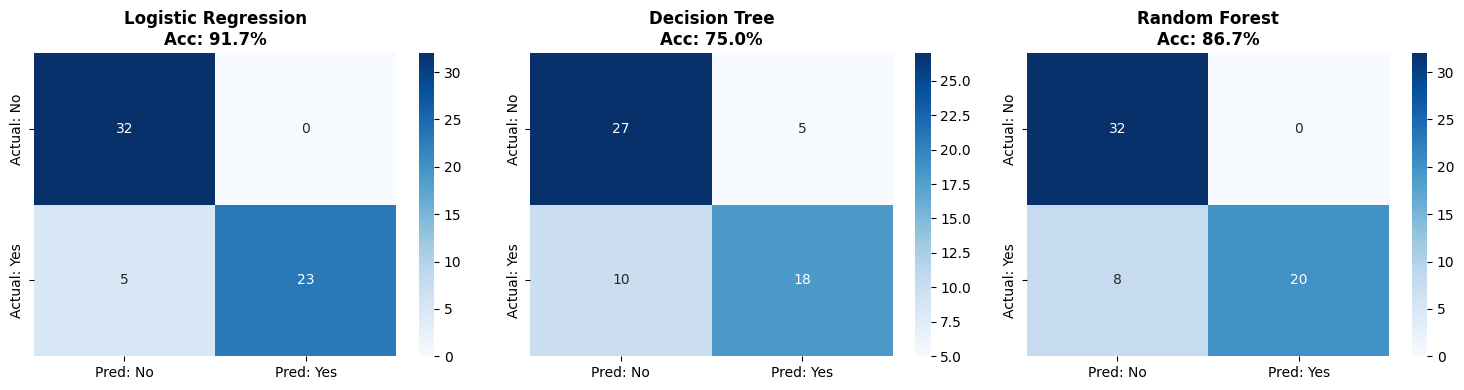

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, results.items()):
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: No', 'Pred: Yes'],
                yticklabels=['Actual: No', 'Actual: Yes'])
    ax.set_title(f"{name}\nAcc: {res['accuracy']:.1%}", fontweight='bold')

plt.tight_layout()
plt.show()

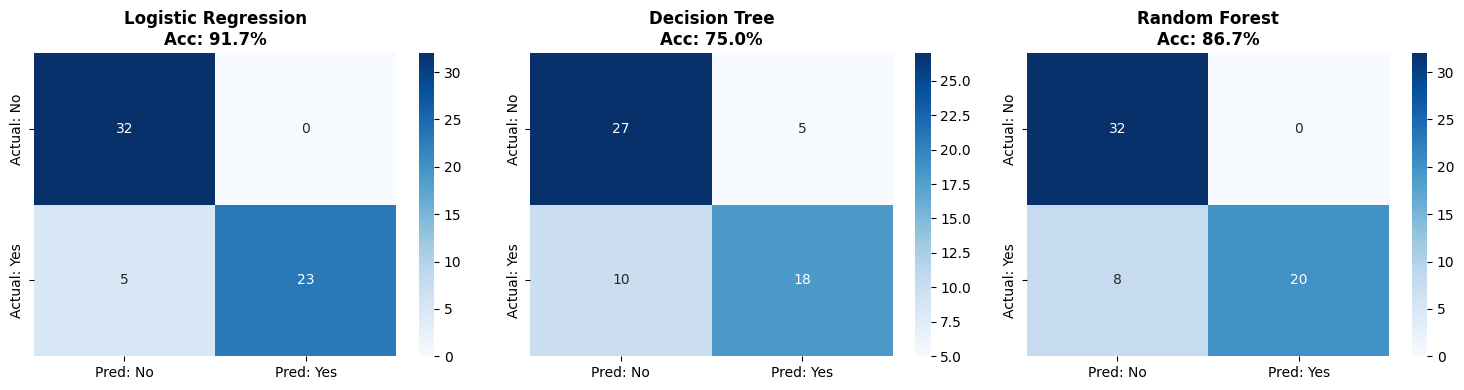

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, results.items()):
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: No', 'Pred: Yes'],
                yticklabels=['Actual: No', 'Actual: Yes'])
    ax.set_title(f"{name}\nAcc: {res['accuracy']:.1%}", fontweight='bold')

plt.tight_layout()
plt.show()

In [19]:
summary = pd.DataFrame({
    name: {
        'Accuracy':  f"{res['accuracy']:.1%}",
        'Precision': f"{res['precision']:.1%}",
        'Recall':    f"{res['recall']:.1%}",
        'F1 Score':  f"{res['f1']:.1%}"
    }
    for name, res in results.items()
}).T

print(summary)

                    Accuracy Precision Recall F1 Score
Logistic Regression    91.7%    100.0%  82.1%    90.2%
Decision Tree          75.0%     78.3%  64.3%    70.6%
Random Forest          86.7%    100.0%  71.4%    83.3%


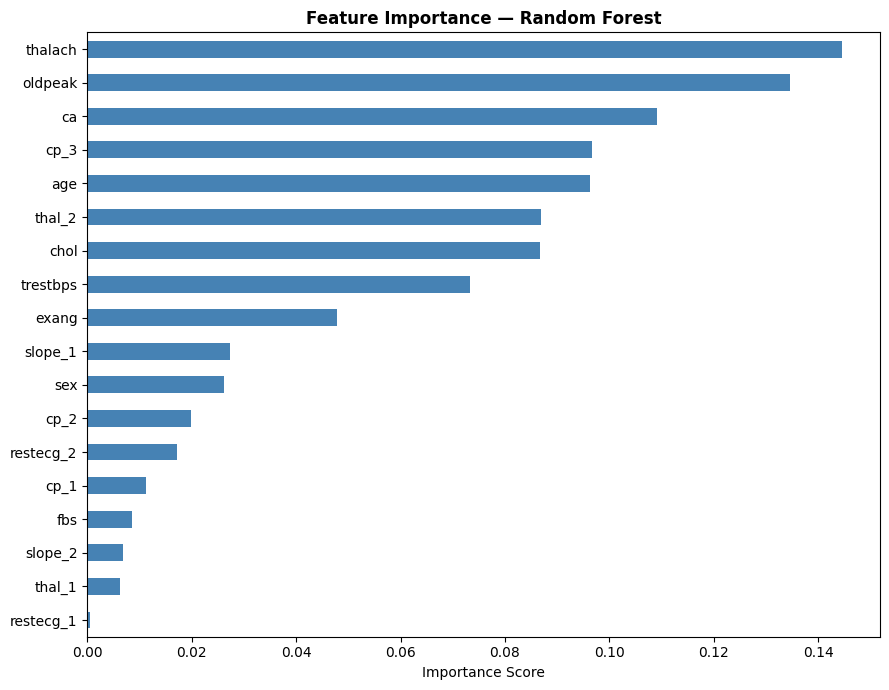

In [20]:
rf = results['Random Forest']['model']

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(9, 7), color='steelblue')
plt.title('Feature Importance — Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [27]:
# In a notebook or script — put all files in the same folder
from run_model import predict_patient, evaluate_all

# Test a single patient
result = predict_patient({
    'age': 63, 'sex': 1, 'cp': 0, 'trestbps': 145,
    'chol': 233, 'fbs': 1, 'restecg': 0, 'thalach': 150,
    'exang': 0, 'oldpeak': 2.3, 'slope': 0, 'ca': 0, 'thal': 1
}, model_key='rf')   # swap 'lr', 'dt', or 'rf'

print(result)
# {'model': 'RF', 'prediction': 1, 'probability': 0.72, 'risk_label': '🔴 HIGH RISK...'}

# Evaluate on a new CSV file
# evaluate_all('new_patients.csv', model_key='lr')  # Uncomment when you have the CSV file

{'model': 'RF', 'prediction': 0, 'probability': np.float64(0.25), 'risk_label': '🟢 LOW RISK'}
